#### Import Libraries and Load Data

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

print("Libraries Loaded Successfully!")


Libraries Loaded Successfully!


#### Load and Fix Data


In [12]:
df = pd.read_csv('C://Users//johny//OneDrive//Desktop//ML//churn-predictor//data//telco_churn_cleaned.csv')

#fix bool columns to int
for col in df.columns:
  if df[col].dtype == 'bool':
    df[col] = df[col].astype(int)

print(f"Shape: {df.shape}")
print(f"Any missing values: {df.isnull().sum().any()}")
print(df.dtypes.value_counts())



Shape: (7032, 31)
Any missing values: False
int32      21
int64       8
float64     2
Name: count, dtype: int64


#### Split Data into Train and Test
###### 80% for training and 20% for testing.We never test on the same data we trained on. 

In [13]:
X=df.drop(columns=['Churn']) #evrything except target variable
y = df['Churn'] #target variable
# Split into train and test

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print(f"Total rows: {len(df)}")
print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")
print(f"Churn rate in testing : {y_test.mean()*100:.1f}%")
print(f"Churn rate in training:{y_train.mean()*100:.1f}% ")


Total rows: 7032
Training rows: 5625
Testing rows: 1407
Churn rate in testing : 26.6%
Churn rate in training:26.6% 


#### Train All 4 Models
######  We train 4 different models in one go.Each model thinks differently:
###### Logistic Regression — simple, fast, like drawing a straight line
###### Decision Tree — asks yes/no questions like a flowchart
###### Random Forest — 100 decision trees voting together
###### XGBoost — super powerful, wins most ML competitions


In [14]:
#Define all models
models = {
  'LogisticRegression': LogisticRegression(max_iter=1000),
  'Decision Tree': DecisionTreeClassifier(random_state=42),
  'Random Forest': RandomForestClassifier(random_state=42),
  'XGBoost': XGBClassifier(random_state=42)
}
#Train all models and store results

results = {}

for name,model in models.items():
  #Train the model
  model.fit(X_train,y_train)

  #make predictions
  y_pred = model.predict(X_test)
  y_prob = model.predict_proba(X_test)[:,1]

  #Calculate metrics

  results[name] ={
    'Accuracy': accuracy_score(y_test,y_pred),
    'Precision': precision_score(y_test,y_pred),
    'Recall': recall_score(y_test,y_pred),
    'F1_Score': f1_score(y_test,y_pred),
    'ROC_AUC': roc_auc_score(y_test,y_prob) 
  }

  print(f"{name} trained and evaluated.")

print("\nAll models trained")



LogisticRegression trained and evaluated.
Decision Tree trained and evaluated.
Random Forest trained and evaluated.
XGBoost trained and evaluated.

All models trained


#### Compare All Models
###### Display all metrics in a clean table so we can compare.


In [15]:
# convert results to dataframe for better visualization
results_df = pd.DataFrame(results).T.round(4)
print("="*60)
print("Model Evaluation Results")
print("="*60)
print(results_df) 
print("="*60)
print(f"\nBest Accuracy: {results_df['Accuracy'].idxmax()} ({results_df['Accuracy'].max():.4f})")
print(f"Best Precision: {results_df['Precision'].idxmax()} ({results_df['Precision'].max():.4f})")
print(f"Best Recall: {results_df['Recall'].idxmax()} ({results_df['Recall'].max():.4f})")
print(f"Best F1-Score: {results_df['F1_Score'].idxmax()} ({results_df['F1_Score'].max():.4f})")
print(f"Best ROC-AUC: {results_df['ROC_AUC'].idxmax()} ({results_df['ROC_AUC'].max():.4f})")


Model Evaluation Results
                    Accuracy  Precision  Recall  F1_Score  ROC_AUC
LogisticRegression    0.7854     0.6184  0.5027    0.5546   0.8286
Decision Tree         0.7242     0.4821  0.5053    0.4935   0.6539
Random Forest         0.7882     0.6407  0.4626    0.5373   0.8173
XGBoost               0.7633     0.5659  0.4706    0.5139   0.8097

Best Accuracy: Random Forest (0.7882)
Best Precision: Random Forest (0.6407)
Best Recall: Decision Tree (0.5053)
Best F1-Score: LogisticRegression (0.5546)
Best ROC-AUC: LogisticRegression (0.8286)


#### Visualize Model Comparison

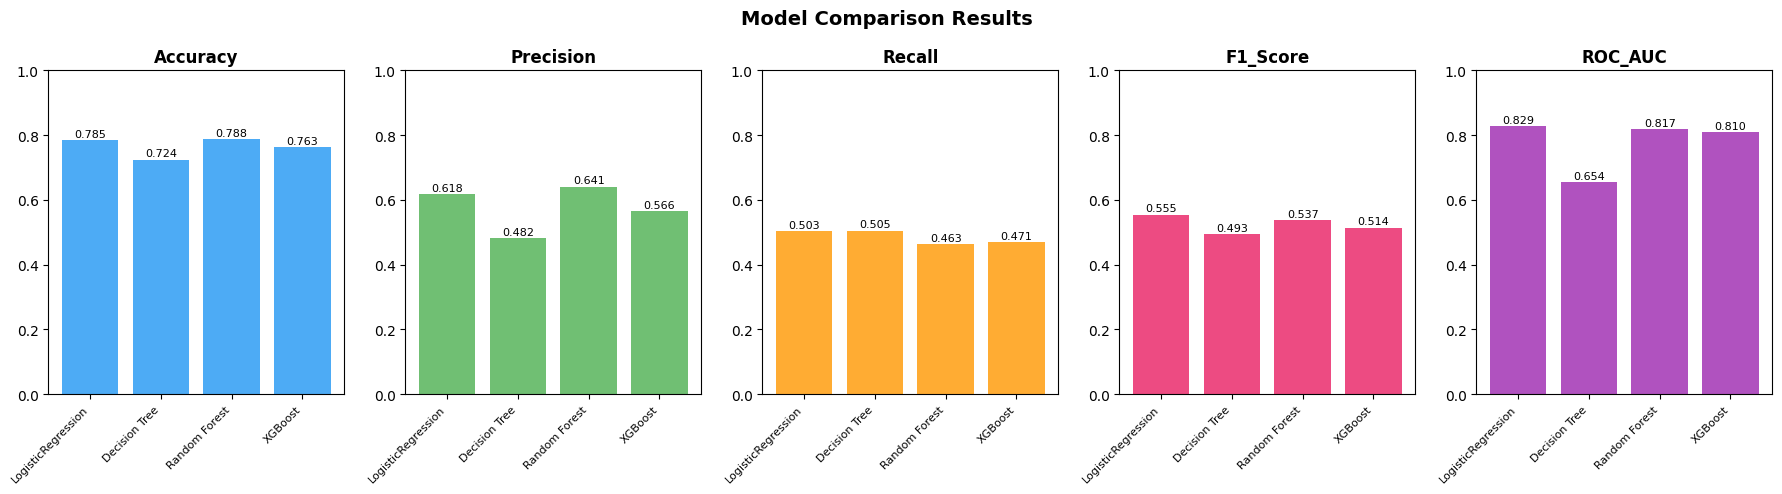

Chart saved!


In [16]:
# Plot model comparison
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

for i, metric in enumerate(metrics):
    values = results_df[metric]
    bars = axes[i].bar(results_df.index, values, color=colors[i], alpha=0.8)
    axes[i].set_title(metric, fontsize=12, fontweight='bold')
    axes[i].set_ylim(0, 1)
    axes[i].set_xticklabels(results_df.index, rotation=45, ha='right', fontsize=8)
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, 
                    bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', fontsize=8)

plt.suptitle('Model Comparison Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('C:\\Users\\johny\\OneDrive\\Desktop\\ML\\churn-predictor\\models\\model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")


#### Save the Best Model


In [18]:
import joblib
import os
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Retrain Logistic Regression
best_model = LogisticRegression(max_iter=1000)
best_model.fit(X_train, y_train)

# Save it
os.makedirs('C:\\Users\\johny\\OneDrive\\Desktop\\ML\\churn-predictor\\models', exist_ok=True)
joblib.dump(best_model, 'C:\\Users\\johny\\OneDrive\\Desktop\\ML\\churn-predictor\\models\\best_model.pkl')
print("✅ Best model saved!")

# Verify
loaded_model = joblib.load('C:\\Users\\johny\\OneDrive\\Desktop\\ML\\churn-predictor\\models\\best_model.pkl')
test_pred = loaded_model.predict(X_test)
print(f"✅ Model loaded and verified!")
print(f"✅ Test accuracy: {accuracy_score(y_test, test_pred):.4f}")

✅ Best model saved!
✅ Model loaded and verified!
✅ Test accuracy: 0.7854
